<a href="https://colab.research.google.com/github/nashwaparvis/DBA-NorthStar-Coursework/blob/main/notebooks/03_Python_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/nashwaparvis/DBA-NorthStar-Coursework.git

Cloning into 'DBA-NorthStar-Coursework'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 141 (delta 44), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (141/141), 2.96 MiB | 10.77 MiB/s, done.
Resolving deltas: 100% (44/44), done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
orders = pd.read_csv("DBA-NorthStar-Coursework/dataset/orders.csv")
deliveries = pd.read_csv("DBA-NorthStar-Coursework/dataset/deliveries.csv")
complaints = pd.read_csv("DBA-NorthStar-Coursework/dataset/complaints.csv")
drivers = pd.read_csv("DBA-NorthStar-Coursework/dataset/drivers.csv")
vehicles = pd.read_csv("DBA-NorthStar-Coursework/dataset/vehicles.csv")
hubs = pd.read_csv("DBA-NorthStar-Coursework/dataset/hubs.csv")
incidents = pd.read_csv("DBA-NorthStar-Coursework/dataset/incidents.csv")
customers = pd.read_csv("DBA-NorthStar-Coursework/dataset/customers.csv")
app_events = pd.read_csv("DBA-NorthStar-Coursework/dataset/app_events.csv")

In [4]:
print("Orders:")
print(orders.head())

print("\nDeliveries:")
print(deliveries.head())

print("\nComplaints:")
print(complaints.head())

Orders:
  order_id customer_id service_type     order_created_at  \
0   O00001       C0292    Passenger  2024-08-20 14:43:00   
1   O00002       C0459    Passenger  2024-05-14 22:16:00   
2   O00003       C0161    Passenger  2025-09-02 14:37:00   
3   O00004       C0520       Parcel  2025-01-11 17:15:00   
4   O00005       C0558       Retail  2025-02-17 19:32:00   

   promised_window_hours pickup_zone dropoff_zone priority_level  order_value  \
0                      6     Airport        South         Medium       126.65   
1                     24       North      AIRPORT            Low       109.30   
2                      4        West      AIRPORT           High        33.50   
3                      2   RiverSide        North         Medium        10.04   
4                     12   Riverside        SOUTH            Low       125.58   

  booking_channel  special_handling_flag  
0             App                      0  
1             App                      0  
2           Pho

In [5]:
print("Orders missing values:")
print(orders.isnull().sum())

print("\nDeliveries missing values:")
print(deliveries.isnull().sum())

print("\nComplaints missing values:")
print(complaints.isnull().sum())

Orders missing values:
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

Deliveries missing values:
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64

Complaints missing values:
complaint_id            0
customer_id             0
order_id                0
complaint_type          0
channel        

In [6]:
orders["pickup_zone"] = orders["pickup_zone"].str.title()
orders["dropoff_zone"] = orders["dropoff_zone"].str.title()
hubs["zone"] = hubs["zone"].str.title()
vehicles["assigned_zone"] = vehicles["assigned_zone"].str.title()
drivers["base_zone"] = drivers["base_zone"].str.title()

print(orders[["pickup_zone", "dropoff_zone"]].head())
print(hubs[["hub_name", "zone"]].head())

  pickup_zone dropoff_zone
0     Airport        South
1       North      Airport
2        West      Airport
3   Riverside        North
4   Riverside        South
         hub_name     zone
0  North Exchange    North
1      South Link    South
2       East Dock     East
3       West Gate     West
4    Central Core  Central


In [7]:
merged = deliveries.merge(orders, on="order_id", how="left")
merged = merged.merge(hubs, on="hub_id", how="left")
merged = merged.merge(drivers, on="driver_id", how="left")
merged = merged.merge(vehicles, on="vehicle_id", how="left")

print(merged.head())
print("Merged dataset shape:", merged.shape)

  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  ...  driver_rating  shift_preference  \
0                            1  ...           4.75           Morning

In [8]:
merged["failure_flag"] = merged["delivery_status"].apply(
    lambda x: 1 if x in ["Failed", "Delayed"] else 0
)

print(merged[["delivery_status", "failure_flag"]].head(10))

  delivery_status  failure_flag
0          Failed             1
1          OnTime             0
2          OnTime             0
3         Delayed             1
4          OnTime             0
5         Delayed             1
6         Delayed             1
7          OnTime             0
8          OnTime             0
9          Failed             1


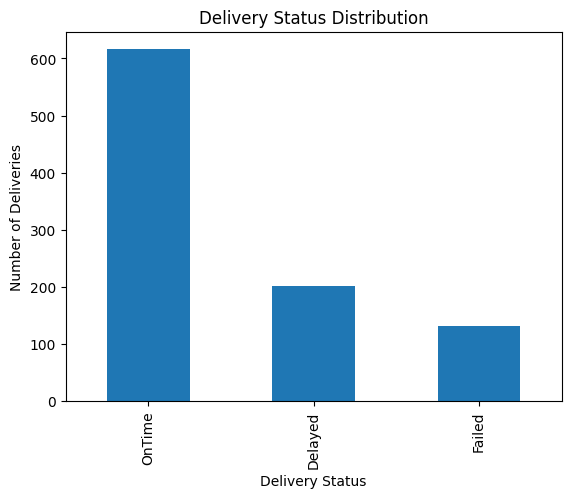

In [9]:
merged["delivery_status"].value_counts().plot(kind="bar")

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")
plt.show()

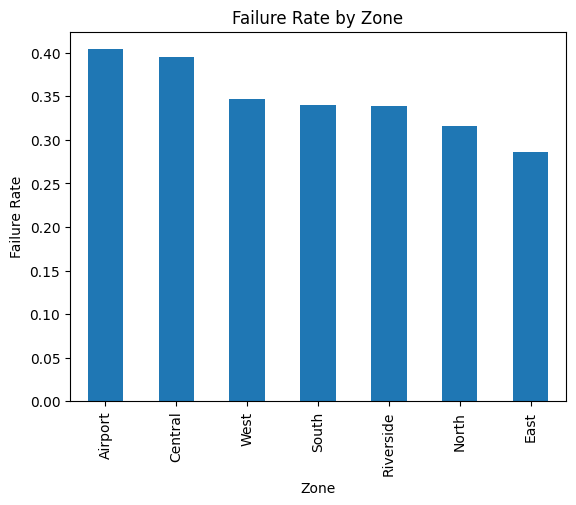

In [10]:
zone_failure = merged.groupby("zone")["failure_flag"].mean().sort_values(ascending=False)

zone_failure.plot(kind="bar")

plt.title("Failure Rate by Zone")
plt.xlabel("Zone")
plt.ylabel("Failure Rate")
plt.show()

In [11]:
json_data = merged.head(50).to_json(
    orient="records",
    indent=4
)

with open("northstar.json", "w") as f:
    f.write(json_data)

print("northstar.json file created successfully")

northstar.json file created successfully


In [12]:
print(merged[[
    "route_distance_km",
    "manual_route_override_count",
    "customer_rating_post_delivery",
    "fuel_or_charge_cost"
]].describe())

       route_distance_km  manual_route_override_count  \
count         950.000000                   950.000000   
mean           13.909316                     0.969474   
std             7.477907                     1.093189   
min             1.200000                     0.000000   
25%             9.135000                     0.000000   
50%            12.840000                     1.000000   
75%            16.835000                     2.000000   
max            41.940000                     7.000000   

       customer_rating_post_delivery  fuel_or_charge_cost  
count                     936.000000           950.000000  
mean                        3.864679            12.841295  
std                         0.894420             4.336468  
min                         1.000000             2.500000  
25%                         3.360000             9.925000  
50%                         4.040000            12.645000  
75%                         4.550000            15.697500  
max   